<a href="https://colab.research.google.com/github/gyuhyeongkim412-creator/financial-data-bootcamp/blob/main/ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 학습 목표

[[ARIMA 실무 프로세스]]의 전체 파이프라인을 **한국 주식 데이터**
로 처음부터 끝까지 실행한다.

단순히 코드를 따라치는 것이 아니라, **각 단계에서 왜 이 판단을 하는지**
 스스로 생각하고 결정하는 연습을 한다.

```
데이터 점검 → 정상성 판별 → ACF/PACF 해석 → 모델 선택
→ 잔차 진단 → Walk-Forward 검증 → 미래 예측 → 한계 인식

#라이브러리 Import

In [ ]:
import warnings
warnings.simplefilter('ignore')          # 모든 경고 억제 (ARIMA 날짜, KPSS, 수렴 등)

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import jarque_bera
from sklearn.metrics import mean_absolute_error, mean_squared_error
from itertools import product

plt.rcParams['figure.dpi'] = 100

In [ ]:
import yfinance as yf # 주식데이터 불러오기

import pandas as pd
import numpy as np #데이터 분석

import matplotlib.pyplot as plt #시각화
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA #아리마모델 불러오기

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import jarque_bera

from sklearn.metrics import mean_absolute_error, mean_squared_error #평가지표
from itertools import product

# 우리나라 대표 3대장

In [ ]:
tickers = {
    '삼성전자': '005930.KS',
    'SK하이닉스': '000660.KS',
    'KOSPI': '^KS11',
}

In [ ]:
data = {}

for name, ticker in tickers.items():
    df = yf.download(ticker, start='2020-01-01')
    data[name] = df['Close'].squeeze()
    print(f"{name:10s}: {len(data[name])}일, {data[name].index[0].date()} ~ {data[name].index[-1].date()}")

# DataFrame으로 통합
prices = pd.DataFrame(data).dropna()
print(f"\n통합 데이터: {prices.shape[0]}일 × {prices.shape[1]}종목")
prices.tail()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


삼성전자      : 1502일, 2020-01-02 ~ 2026-02-19
SK하이닉스    : 1502일, 2020-01-02 ~ 2026-02-19


[*********************100%***********************]  1 of 1 completed

KOSPI     : 1503일, 2020-01-02 ~ 2026-02-19

통합 데이터: 1502일 × 3종목


,삼성전자,SK하이닉스,KOSPI
Date,,,
2026-02-10,165800.0,876000.0,5301.689941
2026-02-11,167800.0,860000.0,5354.490234
2026-02-12,178600.0,888000.0,5522.270020
2026-02-13,181200.0,880000.0,5507.009766
2026-02-19,190200.0,899500.0,5665.600098


# 세개 종목 시각화

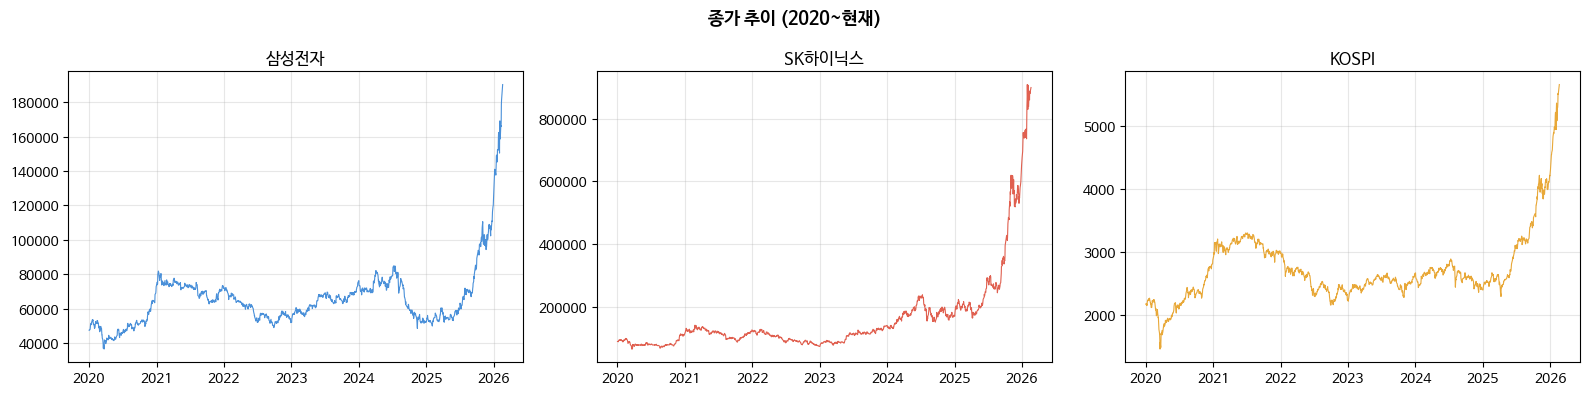

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color in zip(axes, prices.columns, ['#4a90d9', '#e06050', '#e8a838']):
    ax.plot(prices.index, prices[col], color=color, linewidth=0.8)
    ax.set_title(col, fontsize=12)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(alpha=0.3)

plt.suptitle('종가 추이 (2020~현재)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 로그 수익률 계산
log_returns = np.log(prices / prices.shift(1)).dropna()

print("=== 기초 통계 ===")
stats = pd.DataFrame({
    '평균(일)': log_returns.mean(),
    '평균(연)': log_returns.mean() * 252,
    '표준편차(일)': log_returns.std(),
    '표준편차(연)': log_returns.std() * np.sqrt(252),
    '왜도': log_returns.skew(),
    '첨도': log_returns.kurtosis(),
    '최소': log_returns.min(),
    '최대': log_returns.max(),
}).round(4)
print(stats)

=== 기초 통계 ===
         평균(일)   평균(연)  표준편차(일)  표준편차(연)      왜도      첨도      최소      최대
삼성전자    0.0009  0.2330   0.0184   0.2920  0.3764  3.1198 -0.1087  0.1077
SK하이닉스  0.0015  0.3882   0.0270   0.4284  0.1269  1.8098 -0.1098  0.1258
KOSPI   0.0006  0.1607   0.0132   0.2097 -0.3160  6.0966 -0.0918  0.0825


세종목 모두 상승추세 ~>  비정상 시계열 전형적 패턴!


```
- 2020.3  :  코로나
- 2022. : 금리인상기
```




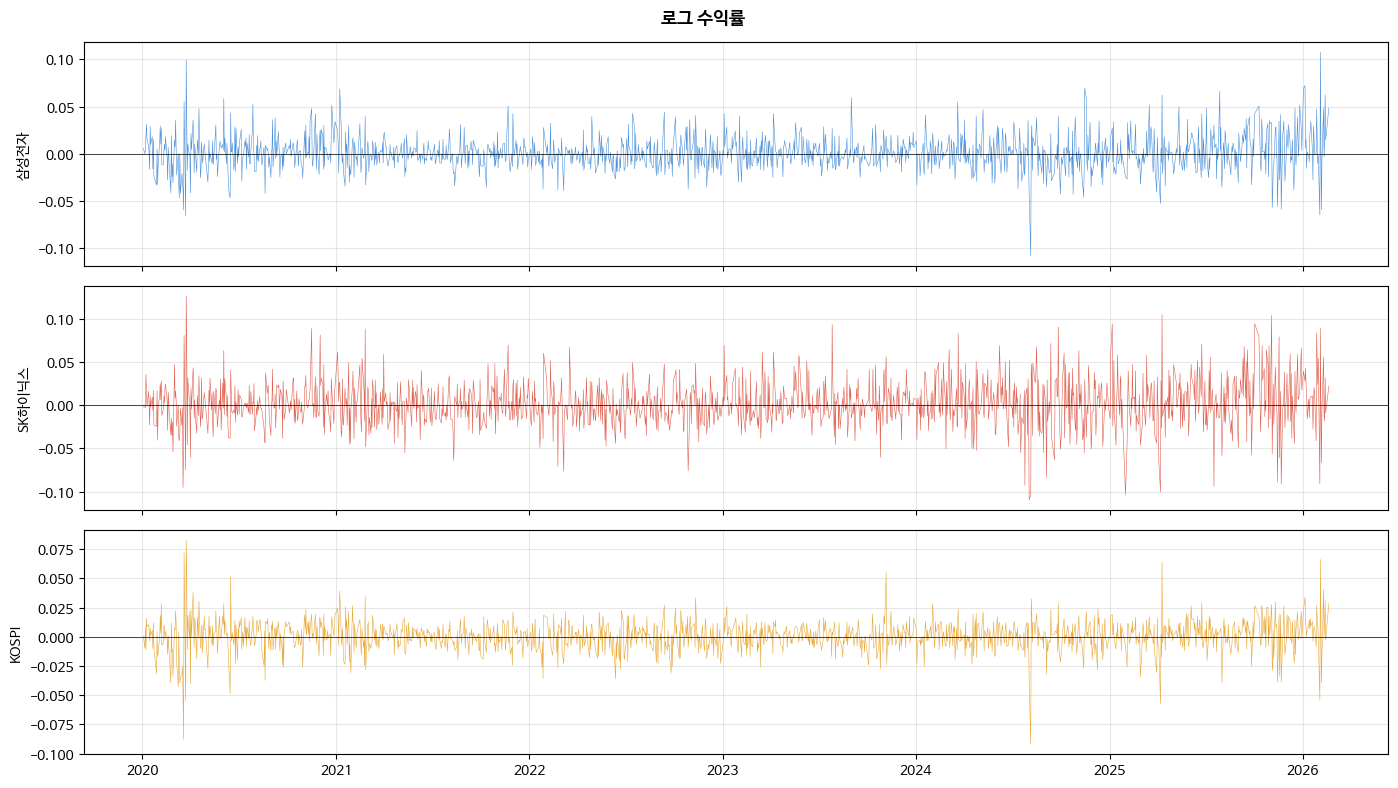

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, col, color in zip(axes, log_returns.columns, ['#4a90d9', '#e06050', '#e8a838']):
    ax.plot(log_returns.index, log_returns[col], color=color, linewidth=0.4)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel(col, fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('로그 수익률', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



> [!abstract] 실습 과제
> 1. 위 기초 통계에서 **왜도**와 **첨도**를 확인하세요.
>    - 왜도 < 0 → 의미는?
>    - 첨도 > 0 (excess) → 의미는?
> 2. 세 종목 중 **변동성이 가장 큰** 종목은? 그 이유를 추측해 보세요.
> 3. 아래 코드로 다른 종목(예: 카카오 `035720.KS`)도 추가해 비교해 보세요.
>
> ```python
> kakao = yf.download('035720.KS', start='2020-01-01')['Close'].squeeze()
> kakao_ret = np.log(kakao / kakao.shift(1)).dropna()
> print(f"카카오 — 평균: {kakao_ret.mean():.6f}, 표준편차: {kakao_ret.std():.4f}")
> ```

왜도 & 첨도
왜도(Skewness) < 0 : 수익률 분포가 왼쪽으로 치우침을 의미
큰 폭의 하락이, 큰 폭의 상승보다 더 자주 발생한다.

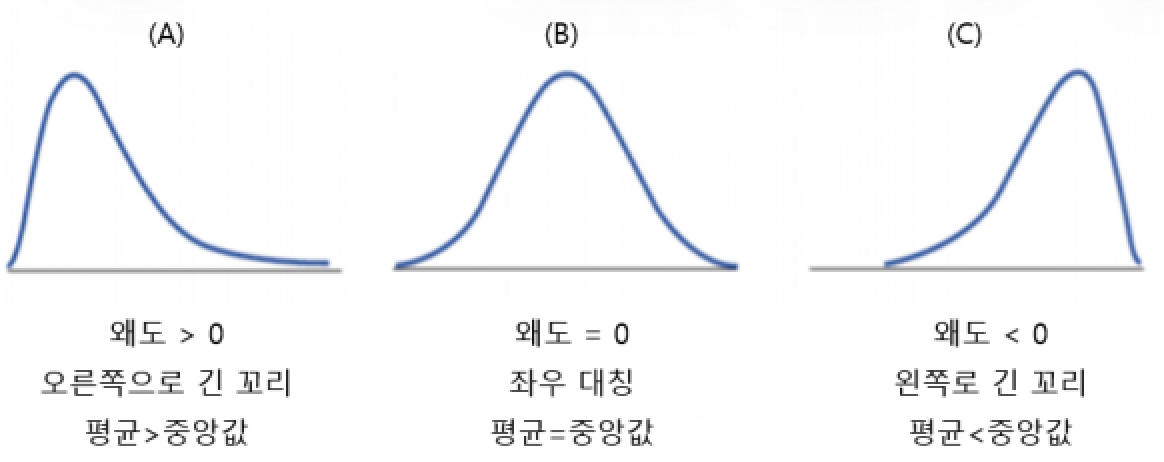

첨도(Kurtosis) > 0 : 정규분포보다 꼬리가 두껍다  
극단적인 (급등/급락) 정규분포보다 더 빈번하게 발생한다  
GARCH에서 t분포를 사용하는 근거  

----

# 정상성 검정
- ADF + KPSS 병행 검정

In [ ]:
def stationarity_test(series, name=""):
    """ADF + KPSS 병행 검정"""
    # ADF
    adf_stat, adf_p, *_ = adfuller(series.dropna(), autolag='AIC')
    adf_result = '정상' if adf_p < 0.05 else '비정상'

    # KPSS
    kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression='c', nlags='auto')
    kpss_result = '정상' if kpss_p > 0.05 else '비정상'

    # 종합 판정
    if adf_p < 0.05 and kpss_p > 0.05:
        verdict = '정상 (확실) ✓'
    elif adf_p >= 0.05 and kpss_p <= 0.05:
        verdict = '비정상 (확실) ✗'
    else:
        verdict = '판단 보류 △'

    return {
        '변수': name,
        'ADF stat': round(adf_stat, 3),
        'ADF p': round(adf_p, 4),
        'ADF': adf_result,
        'KPSS stat': round(kpss_stat, 3),
        'KPSS p': round(kpss_p, 4),
        'KPSS': kpss_result,
        '종합': verdict,
    }

In [ ]:
print("=" * 70)
print("원본 (가격)")
print("=" * 70)
price_tests = pd.DataFrame([
    stationarity_test(prices[col], col) for col in prices.columns
])
print(price_tests.to_string(index=False))

print("\n" + "=" * 70)
print("로그 수익률")
print("=" * 70)
return_tests = pd.DataFrame([
    stationarity_test(log_returns[col], col) for col in log_returns.columns
])
print(return_tests.to_string(index=False))

원본 (가격)


/tmp/ipython-input-3112720727.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression='c', nlags='auto')
/tmp/ipython-input-3112720727.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression='c', nlags='auto')
/tmp/ipython-input-3112720727.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression='c', nlags='auto')


    변수  ADF stat  ADF p ADF  KPSS stat  KPSS p KPSS         종합
  삼성전자     3.979    1.0 비정상      1.267    0.01  비정상 비정상 (확실) ✗
SK하이닉스     4.129    1.0 비정상      2.714    0.01  비정상 비정상 (확실) ✗
 KOSPI     4.107    1.0 비정상      1.208    0.01  비정상 비정상 (확실) ✗

로그 수익률
    변수  ADF stat  ADF p ADF  KPSS stat  KPSS p KPSS      종합
  삼성전자   -37.792    0.0  정상      0.550  0.0304  비정상 판단 보류 △
SK하이닉스   -39.948    0.0  정상      0.689  0.0146  비정상 판단 보류 △
 KOSPI   -20.950    0.0  정상      0.473  0.0477  비정상 판단 보류 △


### 직접 해보기 2

> [!abstract] 실습 과제
> 1. 만약 ADF는 "정상"인데 KPSS는 "비정상"이 나왔다면, 무엇을 의미할까요?
>    - 힌트: [[ARIMA]]의 정상성 섹션에서 "추세 정상" 개념을 확인하세요
> 2. 아래 코드로 **가격(원본)** 에 ADF를 적용해보고, p-value가 어떤지 확인하세요.
>    왜 가격은 비정상이 나올까요?
>
> ```python
> # 삼성전자 가격에 ADF 직접 적용
> stat, p, *_ = adfuller(prices['삼성전자'].dropna())
> print(f"삼성전자 가격 ADF: stat={stat:.3f}, p={p:.4f}")
> # → p-value가 0.05보다 훨씬 클 것이다 (비정상)
> ```
>
> 3. 수익률이 아닌 **1차 차분** ($P_t - P_{t-1}$)도 정상인지 확인해 보세요.
>    로그 수익률과 결과가 같은가요?


1.
1. ADF "정상" + KPSS "비정상" = 추세 정상(Trend Stationary)**
>
> | ADF | KPSS | 해석 |
> | --- | --- | --- |
> | 정상 | 정상 | **확실한 정상** ✓ |
> | 비정상 | 비정상 | **확실한 비정상** ✗ |
> | 정상 | 비정상 | **추세 정상** — 결정적 추세는 있지만 추세 제거 시 정상 |
> | 비정상 | 정상 | **판단 보류** — 검정력 부족 가능, 데이터 늘리거나 차분 시도 |


In [ ]:
# 1차 차분 (단순 차분)
diff_price = prices['삼성전자'].diff().dropna()
stat_diff, p_diff, *_ = adfuller(diff_price)
print(f"1차 차분  ADF: stat={stat_diff:.3f}, p={p_diff:.4f}")

1차 차분  ADF: stat=-3.716, p=0.0039



> 둘 다 **정상**으로 나온다. 수학적으로:
> - 1차 차분: $\Delta P_t = P_t - P_{t-1}$ (원 단위)
> - 로그 수익률: $\ln(P_t/P_{t-1}) = \ln P_t - \ln P_{t-1}$ (**로그 단위의 차분**)
>
> 로그 수익률을 선호하는 이유: **시간 가산성** + **스케일 불변** + 정규분포 근사가 더 좋음

# ACF / PACF

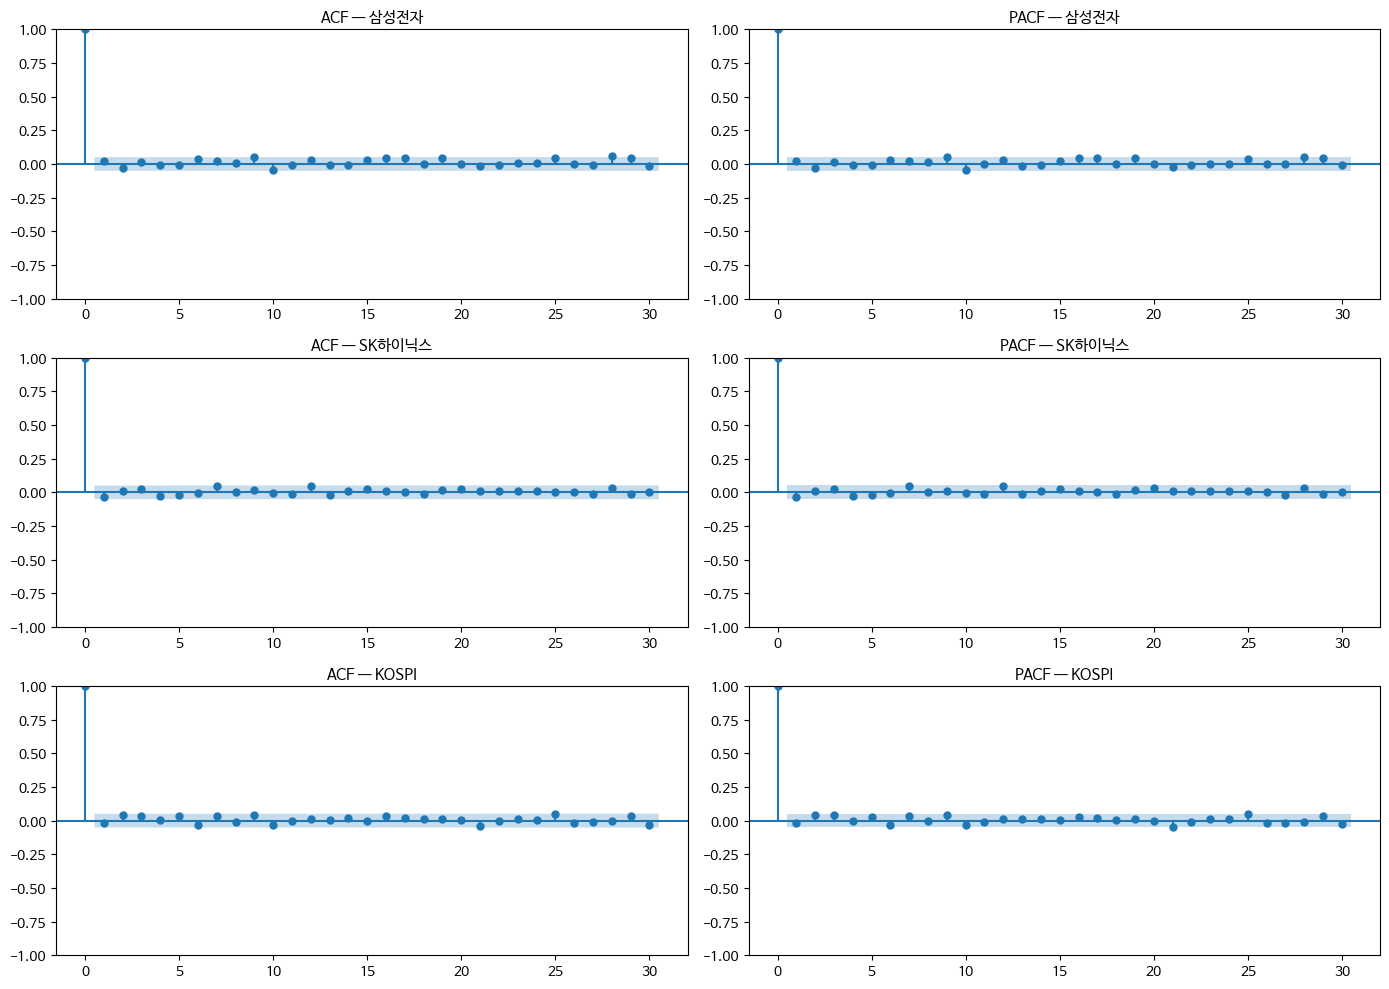

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, col in enumerate(log_returns.columns):
    plot_acf(log_returns[col], lags=30, ax=axes[i, 0], alpha=0.05)
    axes[i, 0].set_title(f'ACF — {col}', fontsize=11)

    plot_pacf(log_returns[col], lags=30, ax=axes[i, 1], alpha=0.05, method='ywm')
    axes[i, 1].set_title(f'PACF — {col}', fontsize=11)

plt.tight_layout()
plt.show()

주식 수익률의 ACF/PACF는 대부분의 lag에서 신뢰구간(파란 영역) 안에 있다.  
이는 자기상관이 매우 약하다는 뜻이다.  

전형적으로 관찰되는 패턴:  

PACF: Lag 1~2에서 간신히 유의하거나 유의하지 않음 →  후보  

ACF: 마찬가지로 Lag 1~2가 약하게 유의 →  후보  
둘 다 지수 감소가 아닌 "거의 모두 비유의" 패턴 → ARMA(p,q)보다 매우 낮은 차수 모델이 적절  

# 다른 케이스 해석
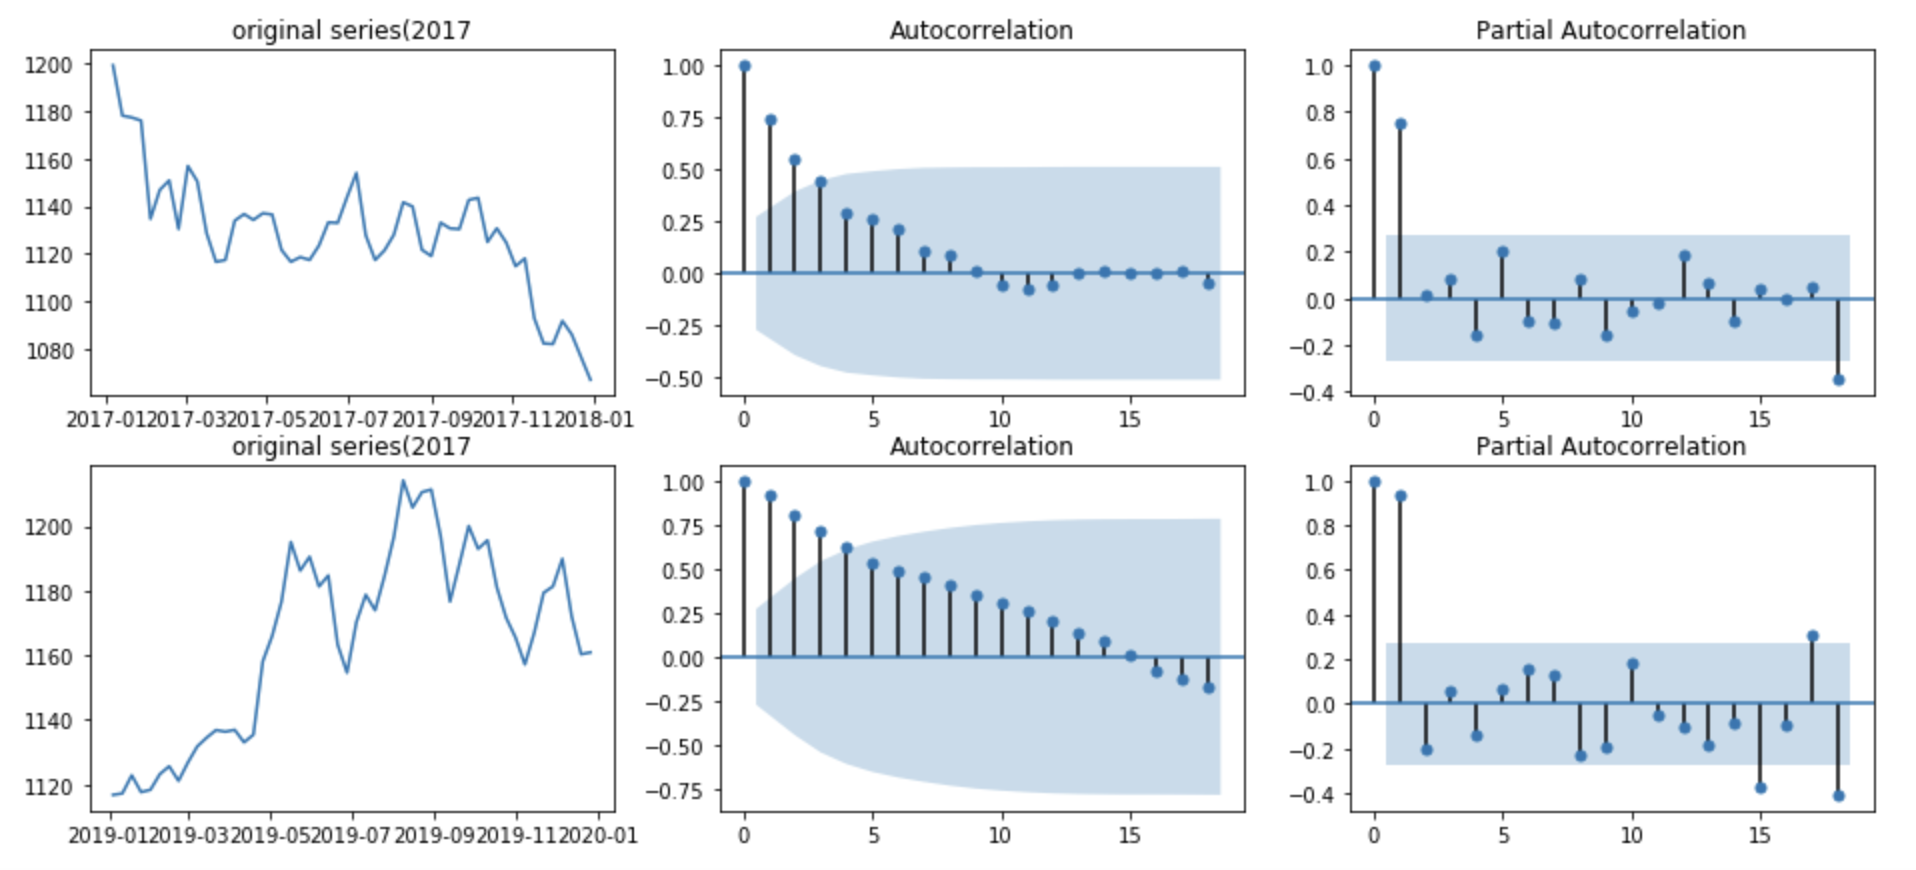

파란색 구간 : 신뢰구간을 의미

ACF 그래프
- lag5까지를 잘봐야한다.(휴리스틱한 해석) - ACF가 천천히 감속하는 형태 -> 전형적인 비정상 시계열 패턴

PACF
- lag1에서만 유의 AR(1)
- lag2 이후 파란색 음영 범위를 벗어난 lag 17~18 구간에서는 노이즈 혹은 계절성 가능성이 있다

-> 판단:  차분이 필요하다

-----

### 수익률 제곱의 ACF — 변동성 구조

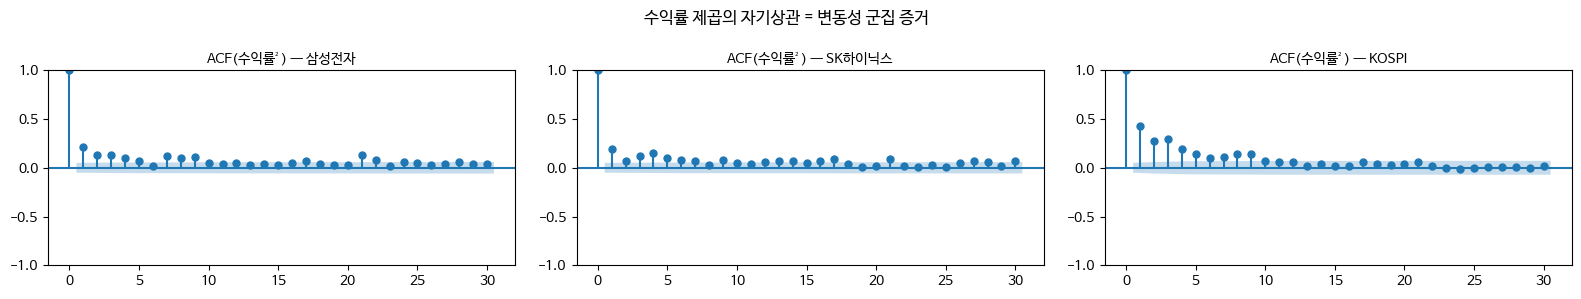

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3))

for ax, col, color in zip(axes, log_returns.columns, ['#4a90d9', '#e06050', '#e8a838']):
    plot_acf(log_returns[col]**2, lags=30, ax=ax, alpha=0.05)
    ax.set_title(f'ACF(수익률²) — {col}', fontsize=10)

plt.suptitle('수익률 제곱의 자기상관 = 변동성 군집 증거', fontsize=12)
plt.tight_layout()
plt.show()



> [!abstract] 실습 과제
> 1. 삼성전자 수익률의 ACF/PACF를 보고, 눈으로 (p, q) 후보를 정해 보세요.
>    - PACF에서 유의한 lag는? → $p$ 후보
>    - ACF에서 유의한 lag는? → $q$ 후보
>    - 답을 적어두고, Step 4의 Grid Search 결과와 비교해 보세요.
>
> 2. 아래 코드로 **절대 수익률**의 ACF도 그려보세요. 수익률 제곱과 비슷한가요?
>
> ```python
> fig, ax = plt.subplots(figsize=(10, 3))
> plot_acf(log_returns['삼성전자'].abs(), lags=30, ax=ax, alpha=0.05)
> ax.set_title('ACF(|수익률|) — 삼성전자')
> plt.show()
> ```


# Grid Search 결과와 비교


### 삼성전자 수익률에 ARIMA 적용

$d = 0$ 고정 (수익률은 이미 정상), $p \in [0,5]$, $q \in [0,5]$ 탐색

In [ ]:
tickers = {
    '삼성전자': '005930.KS',
    'SK하이닉스': '000660.KS',
    'KOSPI': '^KS11',
}

data = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start='2020-01-01')
    data[name] = df['Close'].squeeze()
    print(f"{name:10s}: {len(data[name])}일, {data[name].index[0].date()} ~ {data[name].index[-1].date()}")

# DataFrame으로 통합
prices = pd.DataFrame(data).dropna()
print(f"\n통합 데이터: {prices.shape[0]}일 × {prices.shape[1]}종목")
prices.tail()

[*********************100%***********************]  1 of 1 completed


삼성전자      : 1502일, 2020-01-02 ~ 2026-02-19


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

SK하이닉스    : 1502일, 2020-01-02 ~ 2026-02-19
KOSPI     : 1503일, 2020-01-02 ~ 2026-02-19

통합 데이터: 1502일 × 3종목


,삼성전자,SK하이닉스,KOSPI
Date,,,
2026-02-10,165800.0,876000.0,5301.689941
2026-02-11,167800.0,860000.0,5354.490234
2026-02-12,178600.0,888000.0,5522.270020
2026-02-13,181200.0,880000.0,5507.009766
2026-02-19,188450.0,891000.0,5661.299805


In [ ]:
target = log_returns['삼성전자']

p_range = range(0, 6)
q_range = range(0, 6)
d = 0

results = []
for p, q in product(p_range, q_range):
    if p == 0 and q == 0:
        continue
    try:
        model = ARIMA(target, order=(p, d, q))
        fitted = model.fit()
        results.append({
            'p': p, 'd': d, 'q': q,
            'AIC': round(fitted.aic, 2),
            'BIC': round(fitted.bic, 2),
            'LogLik': round(fitted.llf, 2),
            'params': p + q + 2,  # 상수 + 분산 포함
        })
    except:
        continue

results_df = pd.DataFrame(results)

In [ ]:
results_df

,p,d,q,AIC,BIC,LogLik,params
0,0,0,1,-7731.74,-7715.80,3868.87,3
1,0,0,2,-7731.31,-7710.05,3869.65,4
2,0,0,3,-7729.60,-7703.03,3869.80,5
3,0,0,4,-7727.60,-7695.72,3869.80,6
4,0,0,5,-7725.66,-7688.46,3869.83,7
5,1,0,0,-7731.69,-7715.75,3868.85,3
6,1,0,1,-7731.34,-7710.08,3869.67,4
7,1,0,2,-7729.54,-7702.97,3869.77,5
8,1,0,3,-7727.59,-7695.70,3869.79,6
9,1,0,4,-7726.53,-7689.33,3870.26,7


In [ ]:
print("=== Top 10 by BIC ===")
top_bic = results_df.sort_values('BIC').head(10)
print(top_bic.to_string(index=False))

print("\n=== Top 10 by AIC ===")
top_aic = results_df.sort_values('AIC').head(10)
print(top_aic.to_string(index=False))

# 최적 모델
best_bic = results_df.sort_values('BIC').iloc[0]
best_aic = results_df.sort_values('AIC').iloc[0]

print(f"\nBIC 최적: ARIMA({int(best_bic['p'])},0,{int(best_bic['q'])}), BIC={best_bic['BIC']}")
print(f"AIC 최적: ARIMA({int(best_aic['p'])},0,{int(best_aic['q'])}), AIC={best_aic['AIC']}")

if best_bic['p'] == best_aic['p'] and best_bic['q'] == best_aic['q']:
    print("→ AIC와 BIC가 동일 모델 선택 ✓")
else:
    print("→ AIC와 BIC가 다른 모델 → BIC를 우선 (과적합 방지)")

=== Top 10 by BIC ===
 p  d  q      AIC      BIC  LogLik  params
 0  0  1 -7731.74 -7715.80 3868.87       3
 1  0  0 -7731.69 -7715.75 3868.85       3
 1  0  1 -7731.34 -7710.08 3869.67       4
 0  0  2 -7731.31 -7710.05 3869.65       4
 2  0  0 -7731.23 -7709.98 3869.62       4
 3  0  0 -7729.63 -7703.06 3869.82       5
 0  0  3 -7729.60 -7703.03 3869.80       5
 1  0  2 -7729.54 -7702.97 3869.77       5
 2  0  1 -7729.50 -7702.93 3869.75       5
 2  0  2 -7729.52 -7697.64 3870.76       6

=== Top 10 by AIC ===
 p  d  q      AIC      BIC  LogLik  params
 0  0  1 -7731.74 -7715.80 3868.87       3
 1  0  0 -7731.69 -7715.75 3868.85       3
 1  0  1 -7731.34 -7710.08 3869.67       4
 0  0  2 -7731.31 -7710.05 3869.65       4
 2  0  0 -7731.23 -7709.98 3869.62       4
 3  0  0 -7729.63 -7703.06 3869.82       5
 0  0  3 -7729.60 -7703.03 3869.80       5
 1  0  2 -7729.54 -7702.97 3869.77       5
 2  0  2 -7729.52 -7697.64 3870.76       6
 2  0  1 -7729.50 -7702.93 3869.75       5

BIC 최적: 

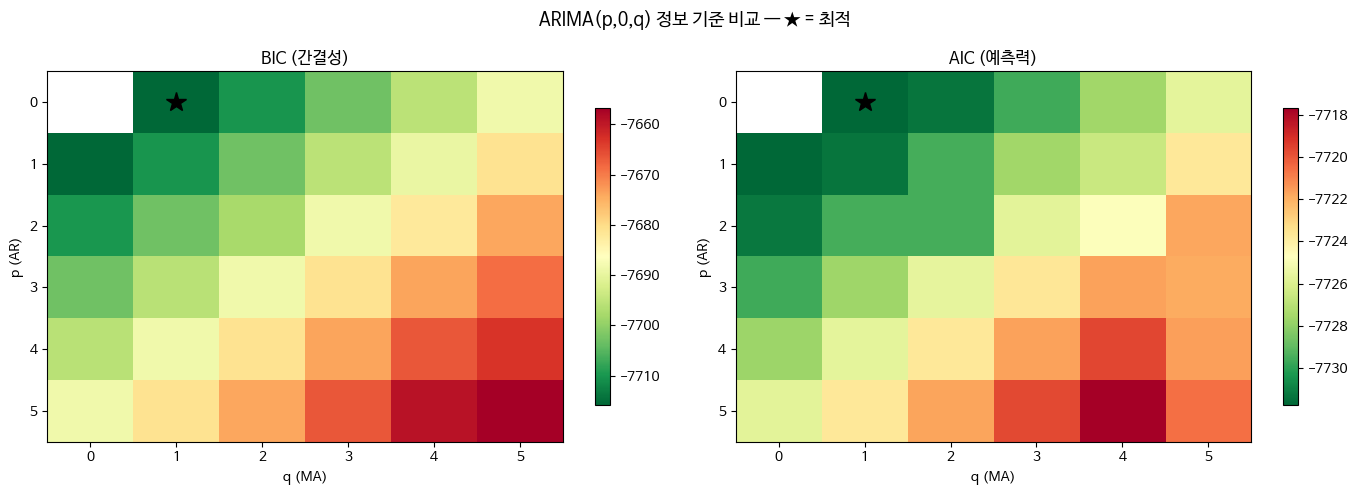

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, criterion, title in zip(axes, ['BIC', 'AIC'], ['BIC (간결성)', 'AIC (예측력)']):
    pivot = results_df.pivot_table(values=criterion, index='p', columns='q')
    im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns.astype(int))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index.astype(int))
    ax.set_xlabel('q (MA)')
    ax.set_ylabel('p (AR)')
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.8)

    # 최적 위치 표시
    best = results_df.sort_values(criterion).iloc[0]
    bp, bq = int(best['p']), int(best['q'])
    row = list(pivot.index).index(bp)
    col = list(pivot.columns).index(bq)
    ax.plot(col, row, 'k*', markersize=15)

plt.suptitle('ARIMA(p,0,q) 정보 기준 비교 — ★ = 최적', fontsize=13)
plt.tight_layout()
plt.show()



> [!abstract] 실습 과제
> 1. Step 3에서 눈으로 정한 (p, q)와 Grid Search 결과가 일치했나요?
>    - 일치하지 않았다면, 왜 그런지 생각해 보세요.
>    - ACF/PACF는 후보군을 좁히는 용도이고, 최종 선택은 정보기준이 결정합니다.
>
> 2. **SK하이닉스**에도 동일한 Grid Search를 적용해 보세요.
>    삼성전자와 최적 차수가 다른가요?
>
> ```python
> target_hynix = log_returns['SK하이닉스']
> # 위 Grid Search 코드에서 target만 바꿔서 실행
> ```
>
> 3. BIC Top 10 모델들의 BIC 값 차이가 **2 미만**인 모델이 여러 개 있나요?
>    - 있다면 → 모델 간 차이가 거의 없다는 뜻 → 가장 단순한 모델 선택이 안전



> **1. ACF/PACF 눈 판단 vs Grid Search**
>
> 대부분 **일치하지 않거나 부분적으로 일치**한다. 이는 정상이다:
> - ACF/PACF는 **후보군을 좁히는 도구**이지, 최종 결정을 내리는 도구가 아니다
> - 주식 수익률처럼 자기상관이 약하면, 눈으로 구분하기 매우 어렵다
> - Grid Search는 **모든 후보를 체계적으로 비교**하므로 더 신뢰할 수 있다
> - 실무에서는 ACF/PACF로 탐색 범위를 설정하고($p \leq 5, q \leq 5$), Grid Search로 최종 결정

In [ ]:
target_hynix = log_returns['SK하이닉스']


results_hynix = []
for p, q in product(range(6), range(6)):
    if p == 0 and q == 0:
        continue
    try:
        m = ARIMA(target_hynix, order=(p, 0, q)).fit()
        results_hynix.append({'p': p, 'q': q, 'BIC': round(m.bic, 2)})
    except:
        continue

df_hynix = pd.DataFrame(results_hynix).sort_values('BIC')
print("SK하이닉스 Top 5:")
print(df_hynix.head().to_string(index=False))

SK하이닉스 Top 5:
 p  q      BIC
 1  0 -6565.09
 0  1 -6565.06
 0  2 -6557.96
 2  0 -6557.90
 1  1 -6557.80


# 모델 해석

In [ ]:
best_order = (int(best_bic['p']), 0, int(best_bic['q']))
print(f"선택된 모델: ARIMA{best_order}")

model = ARIMA(target, order=best_order)
fitted = model.fit()
print(fitted.summary()) #summary() 모델 출력 정리

선택된 모델: ARIMA(0, 0, 1)
                               SARIMAX Results                                
Dep. Variable:                   삼성전자   No. Observations:                 1501
Model:                 ARIMA(0, 0, 1)   Log Likelihood                3868.871
Date:                Thu, 19 Feb 2026   AIC                          -7731.743
Time:                        05:22:25   BIC                          -7715.801
Sample:                             0   HQIC                         -7725.804
                               - 1501                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.000      1.865      0.062   -4.68e-05       0.002
ma.L1          0.0229      0.018      1.269      0.205      -0.012       0.058
sigma2         0.0003   7.85e

- 내부적으로 SARIMAX 엔진을 사용

Ljung-Box (L1) (Q):                   0.00   
- 잔차 자기상관 검정 : 잔차에 자기상관성이 없다
- 모델이 자기 상관 구조는 잘 제거했다.

Jarque-Bera (JB):               655.11
Prob(Q):                              0.98   Prob(JB):                         0.00

- 정규성 검정 : 잔차가 정규분포가 아님(p-val)
-  



Heteroskedasticity (H):               1.63  
- 이분상성검정 : 분산이 시간에 따라 변하지않는다


Skew:                             0.39
- 왜도가 양의 비대칭 -> ARCH랑 GARCH 모델이 효과가 존재할 가능성있다.

Prob(H) (two-sided):                  0.00   
'
Kurtosis:                         6.14
- 첨도  -> ARCH랑 GARCH 모델이 효과가 존재할 가능성있다.

# 잔차진단

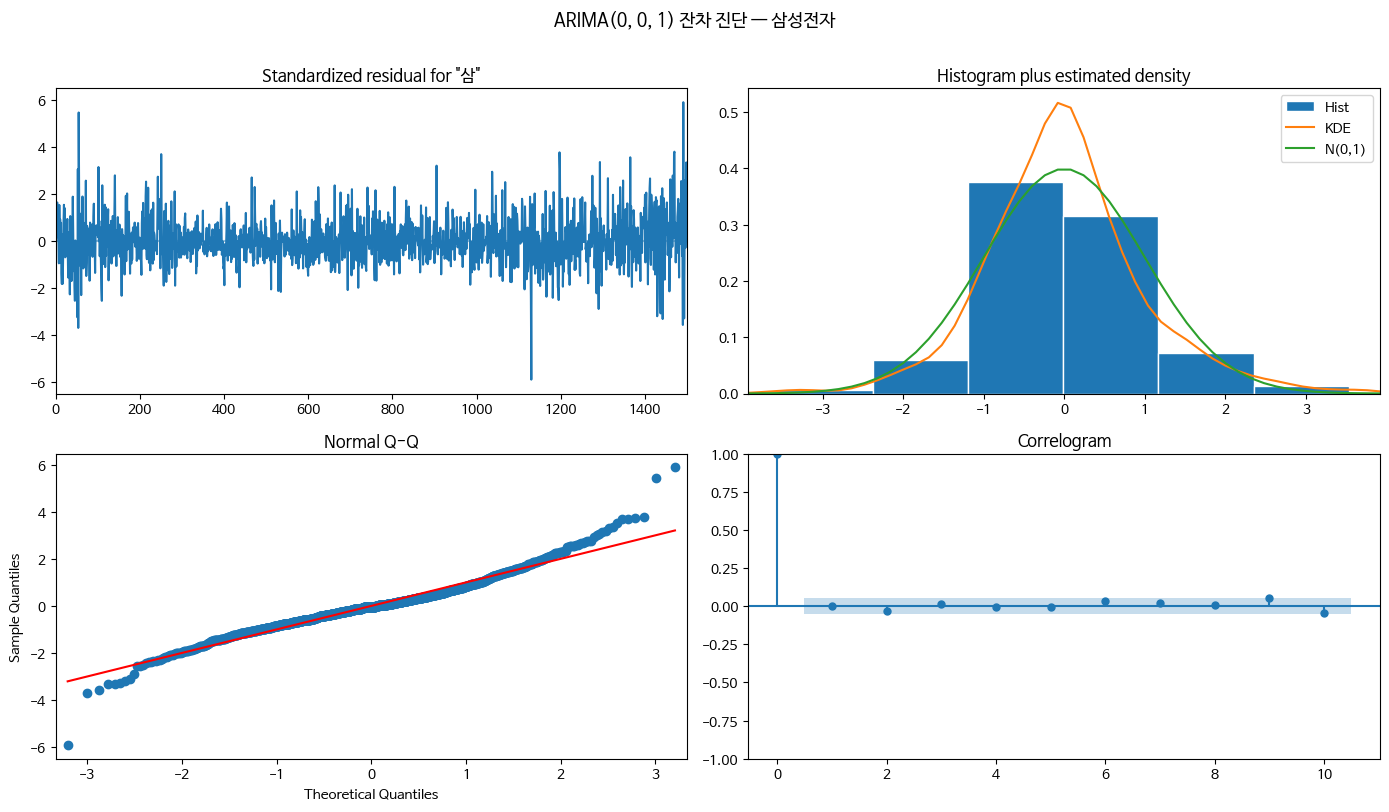

In [ ]:
fig = fitted.plot_diagnostics(figsize=(14, 8))
plt.suptitle(f'ARIMA{best_order} 잔차 진단 — 삼성전자', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Ljung-Box 검정 — 잔차에 자기상관이 남아있는가?

In [ ]:
lb = acorr_ljungbox(fitted.resid, lags=[5, 10, 15, 20], return_df=True)
print("=== Ljung-Box 검정 ===")
print(lb)

lb_pass = (lb['lb_pvalue'] > 0.05).all()
print(f"\n판정: {'✓ 자기상관 없음 (백색잡음)' if lb_pass else '✗ 자기상관 남아있음 → p/q 조정 필요'}")

=== Ljung-Box 검정 ===
      lb_stat  lb_pvalue
5    1.979607   0.851960
10  12.114898   0.277440
15  15.104799   0.443895
20  23.757359   0.253152

판정: ✓ 자기상관 없음 (백색잡음)


# Jarque-Bera 검정 — 잔차가 정규분포인가?


In [ ]:
jb_result = jarque_bera(fitted.resid)
jb_stat, jb_p = float(jb_result[0]), float(jb_result[1])
skew, kurt = fitted.resid.skew(), fitted.resid.kurtosis()
print(f"Jarque-Bera: stat={jb_stat:.2f}, p={jb_p:.6f}")
print(f"왜도={skew:.4f}, 첨도={kurt:.4f}")
print(f"판정: {'✓ 정규분포' if jb_p > 0.05 else '✗ 비정규 (두꺼운 꼬리) → 신뢰구간에 주의'}")

Jarque-Bera: stat=655.11, p=0.000000
왜도=0.3880, 첨도=3.1568
판정: ✗ 비정규 (두꺼운 꼬리) → 신뢰구간에 주의


# ARCH LM 검정 — 변동성 군집이 있는가?

In [ ]:
arch_result = het_arch(fitted.resid, nlags=5)
arch_stat, arch_p = arch_result[0], arch_result[1]
print(f"ARCH LM: stat={arch_stat:.2f}, p={arch_p:.6f}")
print(f"판정: {'✓ 등분산' if arch_p > 0.05 else '✗ ARCH 효과 → GARCH 필요!'}")

ARCH LM: stat=97.44, p=0.000000
판정: ✗ ARCH 효과 → GARCH 필요!


# Walk-Forward 검증

In [ ]:
# 데이버 분할
train_ratio = 0.8
split_idx = int(len(target) * train_ratio)
train, test = target[:split_idx], target[split_idx:]

print(f"Train: {len(train)}일 ({train.index[0].date()} ~ {train.index[-1].date()})")
print(f"Test:  {len(test)}일 ({test.index[0].date()} ~ {test.index[-1].date()})")

Train: 1200일 (2020-01-03 ~ 2024-11-19)
Test:  301일 (2024-11-20 ~ 2026-02-19)


In [ ]:
predictions = []
history = list(train)

print(f"Walk-forward 시작 (ARIMA{best_order}, {len(test)}번 반복)...")
for t in range(len(test)):
    try:
        model = ARIMA(history, order=best_order)
        fitted_wf = model.fit()
        yhat = fitted_wf.forecast(steps=1)[0] #forecast(steps=1) 예측 코드
    except:
        yhat = np.mean(history[-20:])  # fallback: 최근 20일 평균

    predictions.append(yhat)
    history.append(test.iloc[t])

    if (t + 1) % 50 == 0:
        print(f"  {t+1}/{len(test)} 완료")

predictions = pd.Series(predictions, index=test.index, name='ARIMA')
print("완료!")

Walk-forward 시작 (ARIMA(0, 0, 1), 301번 반복)...
  50/301 완료
  100/301 완료
  150/301 완료
  200/301 완료
  250/301 완료
  300/301 완료
완료!


In [ ]:
# 나이브 1: 수익률 = 0 (랜덤워크 가정)
naive_zero = pd.Series(0, index=test.index, name='Naive(0)')

# 나이브 2: 어제 수익률 반복
naive_last = target.shift(1).loc[test.index].rename('Naive(last)')

def evaluate(actual, pred, name):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    return {'모델': name, 'RMSE': round(rmse, 6), 'MAE': round(mae, 6)}

eval_df = pd.DataFrame([
    evaluate(test, predictions, f'ARIMA{best_order}'),
    evaluate(test, naive_zero, 'Naive(0)'),
    evaluate(test, naive_last.dropna(), 'Naive(last)'),
])
print("=== 성능 비교 ===")
print(eval_df.to_string(index=False))

arima_rmse = eval_df.iloc[0]['RMSE']
naive_rmse = eval_df.iloc[1]['RMSE']
print(f"\nARIMA / Naive(0) = {arima_rmse/naive_rmse:.4f}",
      f"→ {'ARIMA 우세 ✓' if arima_rmse < naive_rmse else 'Naive와 비슷하거나 나쁨'}")

=== 성능 비교 ===
            모델     RMSE      MAE
ARIMA(0, 0, 1) 0.023566 0.017412
      Naive(0) 0.023630 0.017469
   Naive(last) 0.032860 0.024892

ARIMA / Naive(0) = 0.9973 → ARIMA 우세 ✓


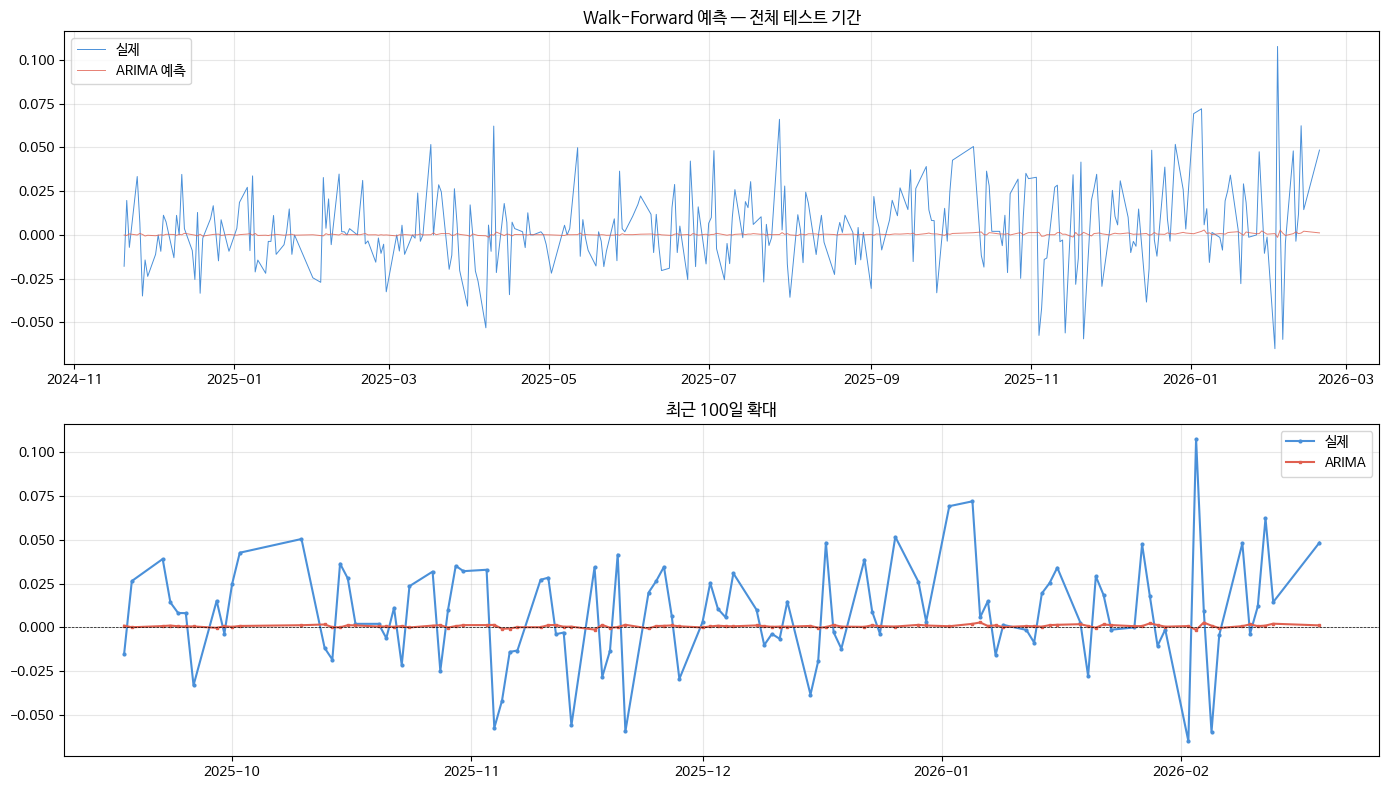

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 전체 테스트 기간
axes[0].plot(test.index, test.values, label='실제', color='#4a90d9', linewidth=0.7)
axes[0].plot(predictions.index, predictions.values, label='ARIMA 예측', color='#e06050', linewidth=0.7, alpha=0.8)
axes[0].set_title('Walk-Forward 예측 — 전체 테스트 기간', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# 마지막 40일 확대
n = 100
axes[1].plot(test.index[-n:], test.values[-n:], 'o-', label='실제', color='#4a90d9', markersize=2)
axes[1].plot(predictions.index[-n:], predictions.values[-n:], 's-', label='ARIMA', color='#e06050', markersize=2)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title(f'최근 {n}일 확대', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def arima_full_pipeline(series, name, p_max=5, q_max=5):
    """ARIMA 전체 파이프라인을 한 함수로 실행"""

    # 1) Grid Search
    best_bic = np.inf
    best_order = (0, 0, 1)
    for p, q in product(range(p_max+1), range(q_max+1)):
        if p == 0 and q == 0:
            continue
        try:
            m = ARIMA(series, order=(p, 0, q)).fit()
            if m.bic < best_bic:
                best_bic = m.bic
                best_order = (p, 0, q)
        except:
            continue

    # 2) 적합
    fitted = ARIMA(series, order=best_order).fit()

    # 3) 진단
    lb_p = acorr_ljungbox(fitted.resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
    jb_p = float(jarque_bera(fitted.resid)[1])
    arch_p_val = het_arch(fitted.resid, nlags=5)[1]

    # 4) Walk-forward (간단 버전)
    split = int(len(series) * 0.8)
    train_s, test_s = series[:split], series[split:]
    preds = []
    hist = list(train_s)
    for t in range(len(test_s)):
        try:
            m = ARIMA(hist, order=best_order).fit()
            preds.append(m.forecast(1)[0])
        except:
            preds.append(np.mean(hist[-20:]))
        hist.append(test_s.iloc[t])

    rmse = np.sqrt(mean_squared_error(test_s, preds))
    naive_rmse = np.sqrt(mean_squared_error(test_s, [0]*len(test_s)))

    return {
        '종목': name,
        '최적 차수': str(best_order),
        'BIC': round(best_bic, 1),
        'LB(p)': round(lb_p, 4),
        'JB(p)': round(jb_p, 4),
        'ARCH(p)': round(arch_p_val, 4),
        'RMSE': round(rmse, 6),
        'Naive RMSE': round(naive_rmse, 6),
        'RMSE비율': round(rmse / naive_rmse, 4),
    }

# 실행
comparison = pd.DataFrame([
    arima_full_pipeline(log_returns[col], col) for col in log_returns.columns
])
print("=== 3종목 ARIMA 비교 ===")
print(comparison.to_string(index=False))

=== 3종목 ARIMA 비교 ===
    종목     최적 차수     BIC  LB(p)  JB(p)  ARCH(p)     RMSE  Naive RMSE  RMSE비율
  삼성전자 (0, 0, 1) -7715.8 0.2774    0.0      0.0 0.023566    0.023630  0.9973
SK하이닉스 (1, 0, 0) -6565.1 0.7974    0.0      0.0 0.034283    0.034416  0.9961
 KOSPI (1, 0, 0) -8708.3 0.1775    0.0      0.0 0.014851    0.014910  0.9961
